In [ ]:
# Task 3

In [6]:
# import packages
import scanpy as sc
import numpy as np
import pandas as pd

In [7]:
#Load the data
adata = sc.read_h5ad("../data/frangieh/adata_qc_done")

In [8]:
#Print the column names
print(adata.obs.columns)

Index(['library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA',
       'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer',
       'disease', 'perturbation_type', 'celltype', 'organism',
       'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito',
       'percent_ribo', 'n_genes', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',
       'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes',
       'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt',
       'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo',
       'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts',
       'doublet_scores', 'predicted_doublets', 'doublet_info'],
      dtype='object')


In [9]:
# No technical batch effects present according to colnames
print(adata.obs["library_preparation_protocol"].value_counts(dropna=False))

library_preparation_protocol
10X 3' v3 sequencing    191174
Name: count, dtype: int64


In [17]:
print(adata.obs["perturbation_2"].unique())

['Control', 'IFNγ', 'Co-culture']
Categories (3, object): ['Co-culture', 'Control', 'IFNγ']


In [18]:
print(adata.obs["perturbation_2"].value_counts())

perturbation_2
IFNγ          74186
Co-culture    67093
Control       49895
Name: count, dtype: int64


In [19]:
# Split the dataset 
adata_IFNG = adata[adata.obs["perturbation_2"] == "IFNγ"].copy()
adata_coculture = adata[adata.obs["perturbation_2"] == "Co-culture"].copy()
adata_control = adata[adata.obs["perturbation_2"] == "Control"].copy()

# Check the sizes
print(adata_IFNG)
print(adata_coculture)
print(adata_control) 

AnnData object with n_obs × n_vars = 74186 × 23711
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'doublet_scores', 'predicted_doublets', 'doublet_info'
    var: 'ensembl_id', 'ncounts', 'ncells', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_coun

In [27]:
# Select highly variable genes 2000
# Normalize and compute hvg for top 5000 genes
sc.pp.normalize_total(adata, target_sum=1e4)
# Logarithmize the data
sc.pp.log1p(adata)

In [30]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata_hvg = adata [:, adata.var["highly_variable"]].copy()
# Save the HVG names
shared_hvgs = adata.var_names[adata.var["highly_variable"]]
print("Number of shared HVGs:", len(shared_hvgs))

Number of shared HVGs: 2000


In [31]:
#Split the data for each condition
adata_control_hvg = adata_hvg[
    adata_hvg.obs["perturbation_2"] == "Control",
    shared_hvgs
].copy()

adata_ifng_hvg = adata_hvg[
    adata_hvg.obs["perturbation_2"] == "IFNγ",
    shared_hvgs
].copy()

adata_coculture_hvg = adata_hvg[
    adata_hvg.obs["perturbation_2"] == "Co-culture",
    shared_hvgs
].copy()

In [ ]:
# Select For each dataset select top 50 features and condition
#Input is perturbation and condition

In [34]:
# Calculate mean log2fold change
# ============================================================
# CALCULATE MEAN LOG2 FOLD-CHANGE PERTURBATION PROFILES
# ============================================================

import numpy as np
import pandas as pd

from scipy.sparse import issparse


# ============================================================
# 1. SETTINGS
# ============================================================

PERTURBATION_COLUMN = "perturbation"
CONTROL_LABEL = "control"
MIN_CELLS = 20
PSEUDOCOUNT = 1e-6

# True if adata.X contains log1p-normalized expression
X_IS_LOG1P = True

# 2. FUNCTION TO CALCULATE LOG2FC PROFILES
def calculate_mean_log2fc_profiles(
    adata,
    perturbation_column="perturbation",
    control_label="control",
    min_cells=5,
    pseudocount=1e-6,
    x_is_log1p=True
):
    """
    Calculate one mean log2 fold-change profile per perturbation.

    Each perturbation is compared with cells labelled 'control'
    in the same AnnData object.

    Rows:
        Perturbations

    Columns:
        Genes

    Values:
        log2(
            (mean linear expression in perturbation + pseudocount)
            /
            (mean linear expression in control + pseudocount)
        )

    Parameters
    ----------
    adata
        AnnData object containing cells and genes.

    perturbation_column
        Column in adata.obs containing perturbation labels.

    control_label
        Exact label of unperturbed control cells.

    min_cells
        Minimum number of cells required for a perturbation.

    pseudocount
        Small value added before calculating the expression ratio.

    x_is_log1p
        Set True if adata.X contains log1p-normalized expression.

    Returns
    -------
    log2fc_profiles
        DataFrame with perturbations as rows and genes as columns.

    cell_counts
        Number of cells used for each retained perturbation.
    """

    # Check required column
    

    if perturbation_column not in adata.obs.columns:
        raise KeyError(
            f"'{perturbation_column}' is not present in adata.obs."
        )

   
    # Clean perturbation labels
   

    perturbation_labels = (
        adata.obs[perturbation_column]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    control_label = str(control_label).strip().lower()

    # --------------------------------------------------------
    # Count cells per perturbation
    # --------------------------------------------------------

    perturbation_counts = perturbation_labels.value_counts()

    print("Cell counts per perturbation:")
    print(perturbation_counts.head(20))

   
    # Identify control cells
    # Convert pandas Series to NumPy boolean array
   

    control_mask = (
        perturbation_labels == control_label
    ).to_numpy(dtype=bool)

    number_of_control_cells = int(control_mask.sum())

    print("\nNumber of control cells:", number_of_control_cells)

    if number_of_control_cells == 0:
        raise ValueError(
            f"No cells labelled '{control_label}' were found."
        )

    if number_of_control_cells < min_cells:
        raise ValueError(
            f"Only {number_of_control_cells} control cells were found."
        )

    # --------------------------------------------------------
    # Convert log1p expression back to linear expression
    # --------------------------------------------------------

    if issparse(adata.X):

        X_linear = adata.X.copy().astype(np.float64)

        if x_is_log1p:
            X_linear.data = np.expm1(X_linear.data)

        X_linear.data = np.nan_to_num(
            X_linear.data,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        X_linear.data[X_linear.data < 0] = 0.0
        X_linear.eliminate_zeros()

    else:

        X_linear = np.asarray(
            adata.X,
            dtype=np.float64
        ).copy()

        if x_is_log1p:
            X_linear = np.expm1(X_linear)

        X_linear = np.nan_to_num(
            X_linear,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        X_linear[X_linear < 0] = 0.0

    # --------------------------------------------------------
    # Calculate mean control expression
    # --------------------------------------------------------

    if issparse(X_linear):

        control_mean = np.asarray(
            X_linear[control_mask, :].mean(axis=0)
        ).ravel()

    else:

        control_mean = np.asarray(
            X_linear[control_mask, :].mean(axis=0)
        ).ravel()

    # --------------------------------------------------------
    # Select perturbations with enough cells
    # --------------------------------------------------------

    retained_perturbations = (
        perturbation_counts[
            perturbation_counts >= min_cells
        ]
        .index
        .tolist()
    )

    # Remove control from perturbation output
    retained_perturbations = [
        perturbation
        for perturbation in retained_perturbations
        if perturbation != control_label
    ]

    print(
        "\nNumber of retained perturbations:",
        len(retained_perturbations)
    )

    if len(retained_perturbations) == 0:
        raise ValueError(
            "No perturbations remained after cell-count filtering."
        )

    # --------------------------------------------------------
    # Calculate mean log2FC for every perturbation
    # --------------------------------------------------------

    profiles = []

    for perturbation in retained_perturbations:

        # Convert pandas Series to NumPy boolean array
        perturbation_mask = (
            perturbation_labels == perturbation
        ).to_numpy(dtype=bool)

        if issparse(X_linear):

            perturbation_mean = np.asarray(
                X_linear[perturbation_mask, :].mean(axis=0)
            ).ravel()

        else:

            perturbation_mean = np.asarray(
                X_linear[perturbation_mask, :].mean(axis=0)
            ).ravel()

        log2fc = np.log2(
            (perturbation_mean + pseudocount)
            /
            (control_mean + pseudocount)
        )

        profiles.append(log2fc)

    # --------------------------------------------------------
    # Create the profile DataFrame
    # --------------------------------------------------------

    log2fc_profiles = pd.DataFrame(
        np.vstack(profiles),
        index=retained_perturbations,
        columns=adata.var_names.astype(str)
    )

    log2fc_profiles.index.name = "perturbation"

    # Cell counts for retained perturbations
    retained_cell_counts = (
        perturbation_counts
        .loc[retained_perturbations]
        .rename("cell_count")
        .to_frame()
    )

    retained_cell_counts.index.name = "perturbation"

    # --------------------------------------------------------
    # Final validation
    # --------------------------------------------------------

    profile_values = log2fc_profiles.to_numpy()

    print("\nProfile matrix shape:", log2fc_profiles.shape)
    print("Minimum log2FC:", np.min(profile_values))
    print("Maximum log2FC:", np.max(profile_values))
    print(
        "Number of non-finite values:",
        np.sum(~np.isfinite(profile_values))
    )

    return log2fc_profiles, retained_cell_counts


# ============================================================
# 3. CONTROL CONDITION
# ============================================================

control_log2fc_profiles, control_cell_counts = (
    calculate_mean_log2fc_profiles(
        adata=adata_control_hvg,
        perturbation_column=PERTURBATION_COLUMN,
        control_label=CONTROL_LABEL,
        min_cells=MIN_CELLS,
        pseudocount=PSEUDOCOUNT,
        x_is_log1p=X_IS_LOG1P
    )
)

print("\nControl log2FC profiles:")
print(control_log2fc_profiles.head())


# ============================================================
# 4. IFNG CONDITION
# ============================================================

ifng_log2fc_profiles, ifng_cell_counts = (
    calculate_mean_log2fc_profiles(
        adata=adata_ifng_hvg,
        perturbation_column=PERTURBATION_COLUMN,
        control_label=CONTROL_LABEL,
        min_cells=MIN_CELLS,
        pseudocount=PSEUDOCOUNT,
        x_is_log1p=X_IS_LOG1P
    )
)

print("\nIFNG log2FC profiles:")
print(ifng_log2fc_profiles.head())


# ============================================================
# 5. CO-CULTURE CONDITION
# ============================================================

coculture_log2fc_profiles, coculture_cell_counts = (
    calculate_mean_log2fc_profiles(
        adata=adata_coculture_hvg,
        perturbation_column=PERTURBATION_COLUMN,
        control_label=CONTROL_LABEL,
        min_cells=MIN_CELLS,
        pseudocount=PSEUDOCOUNT,
        x_is_log1p=X_IS_LOG1P
    )
)

print("\nCo-culture log2FC profiles:")
print(coculture_log2fc_profiles.head())


# ============================================================
# 6. FIND PERTURBATIONS SHARED BY ALL THREE CONDITIONS
# ============================================================

shared_perturbations = (
    control_log2fc_profiles.index
    .intersection(ifng_log2fc_profiles.index)
    .intersection(coculture_log2fc_profiles.index)
)

print(
    "\nNumber of shared perturbations:",
    len(shared_perturbations)
)


control_log2fc_shared = control_log2fc_profiles.loc[
    shared_perturbations
].copy()

ifng_log2fc_shared = ifng_log2fc_profiles.loc[
    shared_perturbations
].copy()

coculture_log2fc_shared = coculture_log2fc_profiles.loc[
    shared_perturbations
].copy()


print("\nShared profile shapes:")
print("Control:", control_log2fc_shared.shape)
print("IFNG:", ifng_log2fc_shared.shape)
print("Co-culture:", coculture_log2fc_shared.shape)

Cell counts per perturbation:
perturbation
control    12941
acta2        342
aebp1        320
cd44         304
a2m          302
atp1b1       291
ctsd         291
b2m          287
cd274        283
cited1       281
ahnak        278
cdh19        276
fgfr1        271
cd59         269
cspg4        267
aga          261
apoe         261
ctso         258
apoc2        257
cdkn1a       254
Name: count, dtype: int64

Number of control cells: 12941

Number of retained perturbations: 234

Profile matrix shape: (234, 2000)
Minimum log2FC: -21.494285881509153
Maximum log2FC: 18.17037349227288
Number of non-finite values: 0

Control log2FC profiles:
gene_symbol       AADAC     AATBC    ABCB11      ABCB6   ABHD12B      ABL2  \
perturbation                                                                 
acta2        -11.792067 -9.768277 -7.374663   0.685660  1.887303 -0.098357   
aebp1          0.223442  1.013633 -7.374663 -12.356831 -7.997860 -0.152734   
cd44          -1.435988  1.797879 -7.374663 -1


Control
Variance explained: 0.3132215249488735


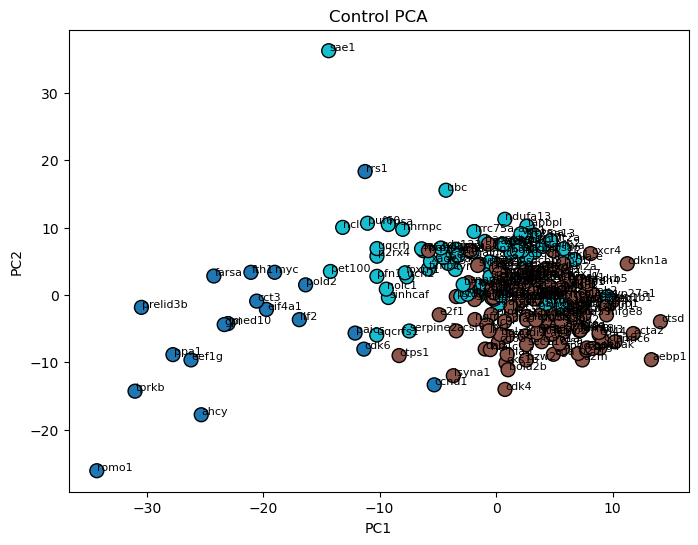

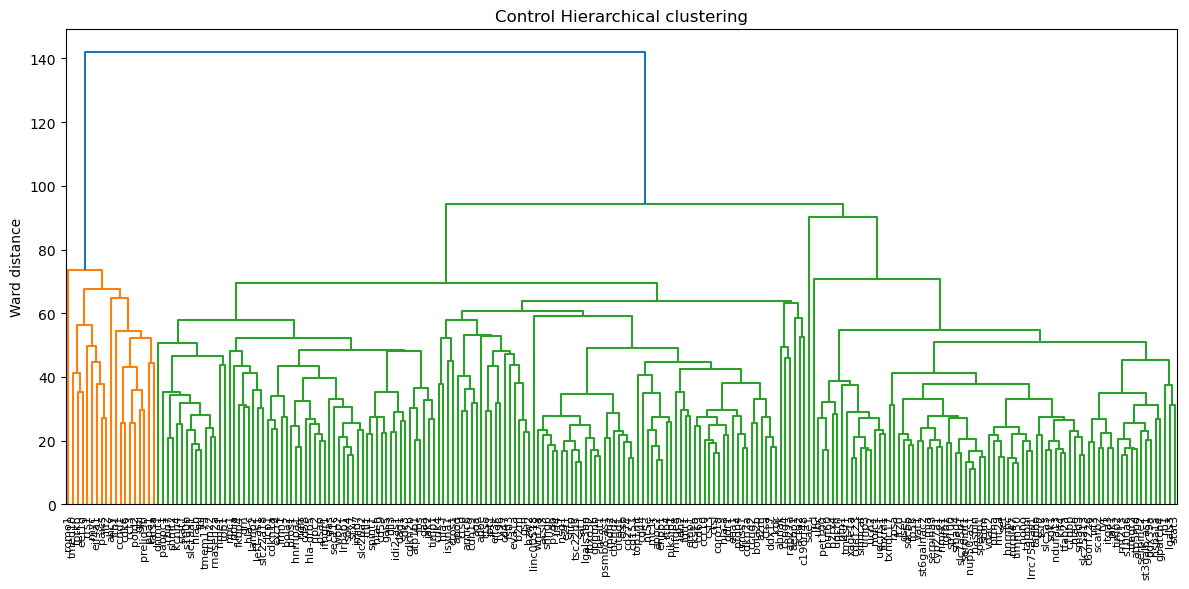

Cluster
2    137
3     78
1     19
Name: count, dtype: int64

IFNG
Variance explained: 0.3266772945739335


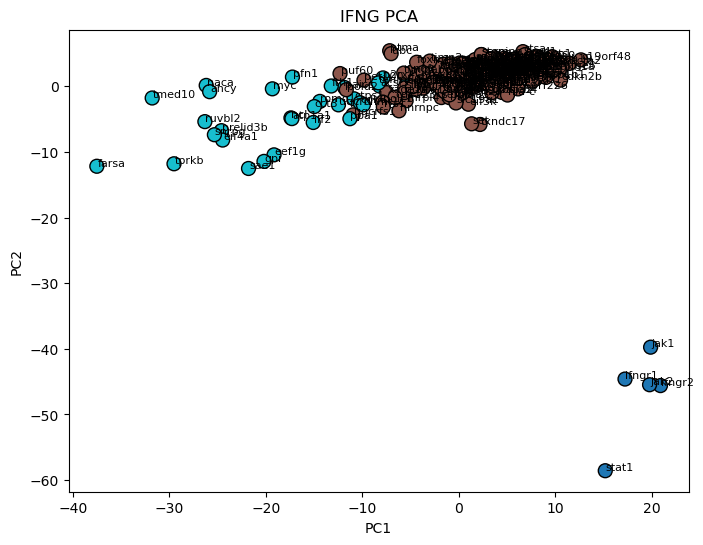

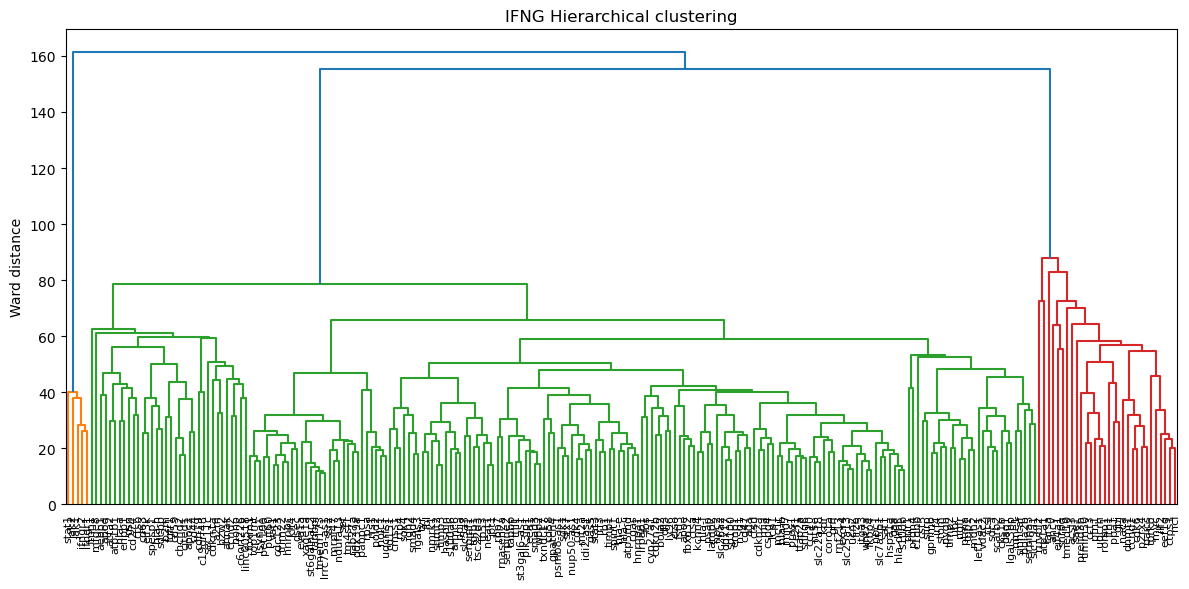

Cluster
2    203
3     30
1      5
Name: count, dtype: int64

Co-culture
Variance explained: 0.32644991146752994


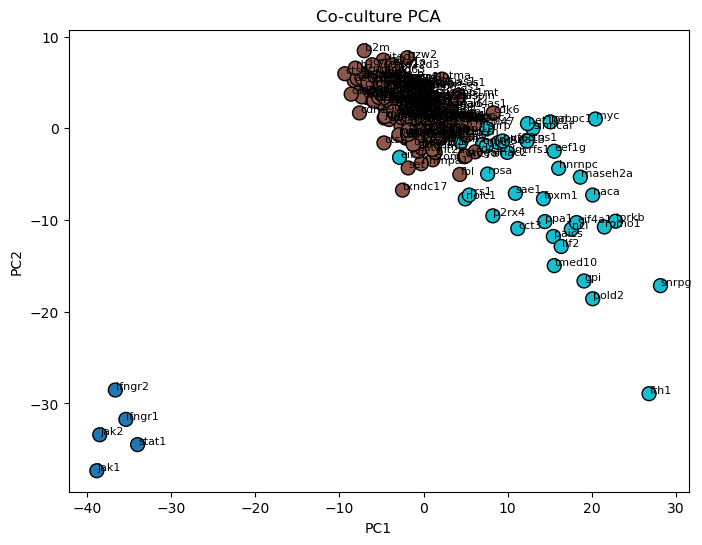

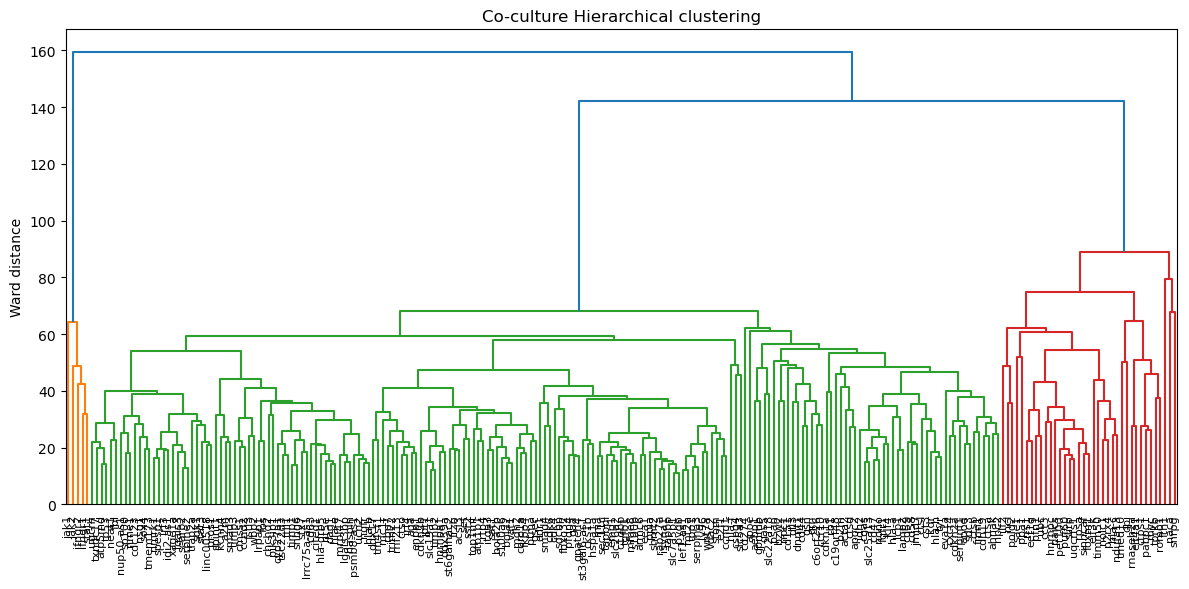

Cluster
2    191
3     37
1      5
Name: count, dtype: int64


In [43]:
# Compute PCA 
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster


def pca_hierarchical_clustering(
    profiles,
    dataset_name,
    n_components=40,
    n_clusters=3
):
    """
    PCA + hierarchical clustering of perturbation profiles.
    """

    # ------------------------------------------------------
    # Standardize genes
    # ------------------------------------------------------

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(profiles)

    # ------------------------------------------------------
    # PCA
    # ------------------------------------------------------

    pca = PCA(
        n_components=min(
            n_components,
            X_scaled.shape[0] - 1,
            X_scaled.shape[1]
        ),
        random_state=42
    )

    X_pca = pca.fit_transform(X_scaled)

    print(f"\n{dataset_name}")
    print(
        "Variance explained:",
        pca.explained_variance_ratio_.sum()
    )

    # ------------------------------------------------------
    # Hierarchical clustering
    # ------------------------------------------------------

    Z = linkage(
        X_pca,
        method="ward"
    )

    cluster_labels = fcluster(
        Z,
        t=n_clusters,
        criterion="maxclust"
    )

    # ------------------------------------------------------
    # PCA plot
    # ------------------------------------------------------

    plt.figure(figsize=(8,6))

    scatter = plt.scatter(
        X_pca[:,0],
        X_pca[:,1],
        c=cluster_labels,
        cmap="tab10",
        s=100,
        edgecolor="black"
    )

    for i, pert in enumerate(profiles.index):
        plt.text(
            X_pca[i,0]+0.05,
            X_pca[i,1]+0.05,
            pert,
            fontsize=8
        )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"{dataset_name} PCA")

    plt.show()

    # ------------------------------------------------------
    # Dendrogram
    # ------------------------------------------------------

    plt.figure(figsize=(12,6))

    dendrogram(
        Z,
        labels=profiles.index.tolist(),
        leaf_rotation=90,
        leaf_font_size=8
    )

    plt.title(f"{dataset_name} Hierarchical clustering")
    plt.ylabel("Ward distance")

    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------
    # Cluster table
    # ------------------------------------------------------

    cluster_table = profiles.copy()

    cluster_table["Cluster"] = cluster_labels

    print(cluster_table["Cluster"].value_counts())

    return (
        X_scaled,
        X_pca,
        Z,
        cluster_labels,
        cluster_table,
        pca
    )


# ===========================================================
# Control
# ===========================================================

(
    control_scaled,
    control_pca,
    control_Z,
    control_clusters,
    control_cluster_table,
    control_pca_model
) = pca_hierarchical_clustering(
    control_log2fc_profiles,
    "Control",
    n_components=40,
    n_clusters=3
)


# ===========================================================
# IFNG
# ===========================================================

(
    ifng_scaled,
    ifng_pca,
    ifng_Z,
    ifng_clusters,
    ifng_cluster_table,
    ifng_pca_model
) = pca_hierarchical_clustering(
    ifng_log2fc_profiles,
    "IFNG",
    n_components=40,
    n_clusters=3
)


# ===========================================================
# Co-culture
# ===========================================================

(
    coculture_scaled,
    coculture_pca,
    coculture_Z,
    coculture_clusters,
    coculture_cluster_table,
    coculture_pca_model
) = pca_hierarchical_clustering(
    coculture_log2fc_profiles,
    "Co-culture",
    n_components=40,
    n_clusters=3
)

In [65]:
# Select biological heterogenous 50 perturbations from clusters
# Select randomly perturbations from each cluster so that there are 50 
# ============================================================
# SELECT 50 UNIQUE PERTURBATIONS IN TOTAL
# EACH PERTURBATION APPEARS IN ONLY ONE CONDITION
# BALANCED ACROSS CONDITIONS AND HIERARCHICAL CLUSTERS
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. SETTINGS
# ============================================================

TOTAL_PERTURBATIONS = 50
CLUSTER_COLUMN = "Cluster"
RANDOM_STATE = 42


# ============================================================
# 2. PREPARE ONE CONDITION
# ============================================================

def prepare_condition_candidates(
    profiles,
    cluster_table,
    condition_name,
    cluster_column="Cluster"
):
    """
    Creates a candidate table for one experimental condition.

    Each row corresponds to one perturbation-condition pair.

    Parameters
    ----------
    profiles : pandas.DataFrame
        Perturbation profiles.
        Rows = perturbations
        Columns = genes

    cluster_table : pandas.DataFrame
        Table containing hierarchical cluster assignments.
        Perturbation names must be stored in the index.

    condition_name : str
        Name of the experimental condition.

    cluster_column : str
        Column containing hierarchical cluster labels.

    Returns
    -------
    candidates : pandas.DataFrame
        Candidate table containing:
        perturbation, condition, cluster, and gene profiles.
    """

    profiles = profiles.copy()
    cluster_table = cluster_table.copy()

    # Convert indices to strings
    profiles.index = profiles.index.astype(str)
    cluster_table.index = cluster_table.index.astype(str)

    if cluster_column not in cluster_table.columns:
        raise KeyError(
            f"Column '{cluster_column}' was not found "
            f"in the cluster table for {condition_name}."
        )

    # Keep perturbations available in both tables
    shared_perturbations = profiles.index.intersection(
        cluster_table.index
    )

    condition_profiles = profiles.loc[
        shared_perturbations
    ].copy()

    condition_clusters = cluster_table.loc[
        shared_perturbations,
        cluster_column
    ].copy()

    # Add metadata
    candidates = condition_profiles.copy()

    candidates.insert(
        0,
        "perturbation",
        candidates.index.astype(str)
    )

    candidates.insert(
        1,
        "condition",
        condition_name
    )

    candidates.insert(
        2,
        cluster_column,
        condition_clusters.values
    )

    candidates = candidates.dropna(
        subset=[cluster_column]
    )

    candidates = candidates.reset_index(
        drop=True
    )

    return candidates


# ============================================================
# 3. PREPARE ALL THREE CONDITIONS
# ============================================================

control_candidates = prepare_condition_candidates(
    profiles=control_log2fc_profiles,
    cluster_table=control_cluster_table,
    condition_name="Control",
    cluster_column=CLUSTER_COLUMN
)

ifng_candidates = prepare_condition_candidates(
    profiles=ifng_log2fc_profiles,
    cluster_table=ifng_cluster_table,
    condition_name="IFNG",
    cluster_column=CLUSTER_COLUMN
)

coculture_candidates = prepare_condition_candidates(
    profiles=coculture_log2fc_profiles,
    cluster_table=coculture_cluster_table,
    condition_name="Coculture",
    cluster_column=CLUSTER_COLUMN
)


# ============================================================
# 4. COMBINE ALL CANDIDATES
# ============================================================

all_candidates = pd.concat(
    [
        control_candidates,
        ifng_candidates,
        coculture_candidates
    ],
    axis=0,
    ignore_index=True
)

# Remove duplicated perturbation-condition pairs if present
all_candidates = all_candidates.drop_duplicates(
    subset=["perturbation", "condition"]
).reset_index(drop=True)

# Create condition-cluster group
all_candidates["_group"] = (
    all_candidates["condition"].astype(str)
    + "_cluster_"
    + all_candidates[CLUSTER_COLUMN].astype(str)
)

print("Total candidate perturbation-condition pairs:")
print(len(all_candidates))

print("\nNumber of unique perturbations available:")
print(
    all_candidates["perturbation"].nunique()
)

print("\nCandidates per condition:")
print(
    all_candidates["condition"]
    .value_counts()
    .sort_index()
)

print("\nCandidates per condition and cluster:")
print(
    pd.crosstab(
        all_candidates["condition"],
        all_candidates[CLUSTER_COLUMN]
    )
)


# ============================================================
# 5. FUNCTION TO SELECT 50 UNIQUE PERTURBATIONS
# ============================================================

def select_unique_balanced_perturbations(
    candidates,
    total_perturbations=50,
    perturbation_column="perturbation",
    condition_column="condition",
    cluster_column="Cluster",
    random_state=42,
    max_attempts=1000
):
    """
    Selects unique perturbations across all conditions.

    Each perturbation is selected only once and is therefore assigned
    to only one condition.

    Selection is balanced as evenly as possible across all
    condition-cluster groups.

    For 3 conditions and 3 clusters, there are 9 groups.
    With 50 perturbations, most groups will contain 5 or 6 samples.

    Parameters
    ----------
    candidates : pandas.DataFrame
        Combined candidate table.

    total_perturbations : int
        Exact number of unique perturbations to select.

    perturbation_column : str
        Column containing perturbation names.

    condition_column : str
        Column containing condition names.

    cluster_column : str
        Column containing hierarchical cluster labels.

    random_state : int
        Random seed.

    max_attempts : int
        Maximum number of random selection attempts.

    Returns
    -------
    selected_data : pandas.DataFrame
        Exactly total_perturbations rows with unique perturbations.
    """

    required_columns = [
        perturbation_column,
        condition_column,
        cluster_column,
        "_group"
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in candidates.columns
    ]

    if missing_columns:
        raise KeyError(
            f"Missing required columns: {missing_columns}"
        )

    data = candidates.copy()

    number_of_unique_perturbations = (
        data[perturbation_column].nunique()
    )

    if total_perturbations > number_of_unique_perturbations:
        raise ValueError(
            f"You requested {total_perturbations} unique perturbations, "
            f"but only {number_of_unique_perturbations} are available."
        )

    groups = sorted(
        data["_group"].unique()
    )

    number_of_groups = len(groups)

    if number_of_groups == 0:
        raise ValueError(
            "No condition-cluster groups were found."
        )

    # --------------------------------------------------------
    # Target allocation
    # --------------------------------------------------------

    base_size = (
        total_perturbations // number_of_groups
    )

    remainder = (
        total_perturbations % number_of_groups
    )

    best_selection = None
    best_balance_score = np.inf

    master_rng = np.random.default_rng(
        random_state
    )

    # --------------------------------------------------------
    # Try multiple random allocations
    # --------------------------------------------------------

    for attempt in range(max_attempts):

        attempt_seed = int(
            master_rng.integers(
                0,
                1_000_000_000
            )
        )

        rng = np.random.default_rng(
            attempt_seed
        )

        # Randomly choose groups that receive one extra sample
        target_per_group = {
            group: base_size
            for group in groups
        }

        if remainder > 0:
            extra_groups = rng.choice(
                groups,
                size=remainder,
                replace=False
            )

            for group in extra_groups:
                target_per_group[group] += 1

        # Randomize group processing order
        group_order = groups.copy()
        rng.shuffle(group_order)

        selected_parts = []
        used_perturbations = set()

        # ----------------------------------------------------
        # First pass: sample according to target quotas
        # ----------------------------------------------------

        for group in group_order:

            group_data = data[
                data["_group"] == group
            ].copy()

            # Exclude perturbations already selected elsewhere
            group_data = group_data[
                ~group_data[perturbation_column].isin(
                    used_perturbations
                )
            ]

            group_data = group_data.sample(
                frac=1,
                random_state=int(
                    rng.integers(
                        0,
                        1_000_000_000
                    )
                )
            )

            number_to_select = min(
                target_per_group[group],
                len(group_data)
            )

            selected_group = group_data.head(
                number_to_select
            )

            selected_parts.append(
                selected_group
            )

            used_perturbations.update(
                selected_group[
                    perturbation_column
                ].tolist()
            )

        if len(selected_parts) == 0:
            continue

        selected_data = pd.concat(
            selected_parts,
            axis=0,
            ignore_index=True
        )

        # ----------------------------------------------------
        # Second pass: fill remaining positions
        # ----------------------------------------------------

        remaining_number = (
            total_perturbations
            - len(selected_data)
        )

        if remaining_number > 0:

            remaining_candidates = data[
                ~data[perturbation_column].isin(
                    used_perturbations
                )
            ].copy()

            remaining_candidates = remaining_candidates.sample(
                frac=1,
                random_state=int(
                    rng.integers(
                        0,
                        1_000_000_000
                    )
                )
            )

            current_group_counts = (
                selected_data["_group"]
                .value_counts()
                .to_dict()
            )

            while (
                remaining_number > 0
                and len(remaining_candidates) > 0
            ):

                # Prefer the currently least represented groups
                remaining_candidates[
                    "_current_group_count"
                ] = remaining_candidates[
                    "_group"
                ].map(
                    current_group_counts
                ).fillna(0)

                minimum_count = remaining_candidates[
                    "_current_group_count"
                ].min()

                least_represented = remaining_candidates[
                    remaining_candidates[
                        "_current_group_count"
                    ] == minimum_count
                ]

                chosen_row = least_represented.sample(
                    n=1,
                    random_state=int(
                        rng.integers(
                            0,
                            1_000_000_000
                        )
                    )
                ).drop(
                    columns=["_current_group_count"]
                )

                chosen_perturbation = chosen_row[
                    perturbation_column
                ].iloc[0]

                chosen_group = chosen_row[
                    "_group"
                ].iloc[0]

                selected_data = pd.concat(
                    [
                        selected_data,
                        chosen_row
                    ],
                    axis=0,
                    ignore_index=True
                )

                used_perturbations.add(
                    chosen_perturbation
                )

                current_group_counts[
                    chosen_group
                ] = (
                    current_group_counts.get(
                        chosen_group,
                        0
                    )
                    + 1
                )

                # Remove all other rows for this perturbation
                remaining_candidates = remaining_candidates[
                    remaining_candidates[
                        perturbation_column
                    ] != chosen_perturbation
                ].copy()

                remaining_number -= 1

        # ----------------------------------------------------
        # Validate selection
        # ----------------------------------------------------

        if len(selected_data) != total_perturbations:
            continue

        if (
            selected_data[perturbation_column].nunique()
            != total_perturbations
        ):
            continue

        # ----------------------------------------------------
        # Calculate balance score
        # ----------------------------------------------------

        observed_counts = (
            selected_data["_group"]
            .value_counts()
            .reindex(
                groups,
                fill_value=0
            )
        )

        ideal_value = (
            total_perturbations
            / number_of_groups
        )

        balance_score = np.sum(
            (
                observed_counts.values
                - ideal_value
            ) ** 2
        )

        if balance_score < best_balance_score:

            best_balance_score = balance_score
            best_selection = selected_data.copy()

        # Perfectly balanced or nearly balanced result
        if (
            observed_counts.max()
            - observed_counts.min()
            <= 1
        ):
            break

    if best_selection is None:
        raise RuntimeError(
            "A valid selection of unique perturbations "
            "could not be generated."
        )

    # Shuffle final order
    best_selection = best_selection.sample(
        frac=1,
        random_state=random_state
    ).reset_index(drop=True)

    return best_selection

# ============================================================
# 6. REMOVE INVALID TARGET GENES BEFORE SELECTING 50
# ============================================================

# Use the genes present in all three full AnnData objects.
# Usually the var_names are identical, but this check is safer.

control_genes_upper = set(
    adata_control.var_names.astype(str).str.upper()
)

ifng_genes_upper = set(
    adata_IFNG.var_names.astype(str).str.upper()
)

coculture_genes_upper = set(
    adata_coculture.var_names.astype(str).str.upper()
)

# A perturbation target must exist in the AnnData object
# corresponding to its assigned condition.

def target_exists_in_assigned_condition(row):

    perturbation_upper = str(
        row["perturbation"]
    ).strip().upper()

    condition_name = str(
        row["condition"]
    ).strip()

    if condition_name == "Control":
        return perturbation_upper in control_genes_upper

    elif condition_name == "IFNG":
        return perturbation_upper in ifng_genes_upper

    elif condition_name == "Coculture":
        return perturbation_upper in coculture_genes_upper

    else:
        return False


all_candidates = all_candidates.copy()

all_candidates["_target_exists"] = all_candidates.apply(
    target_exists_in_assigned_condition,
    axis=1
)

invalid_candidates = all_candidates.loc[
    ~all_candidates["_target_exists"],
    [
        "perturbation",
        "condition",
        CLUSTER_COLUMN
    ]
].copy()

print(
    "\nCandidate perturbations removed because "
    "their target gene is absent from var_names:"
)

print(
    invalid_candidates
    .sort_values(
        by=[
            "condition",
            CLUSTER_COLUMN,
            "perturbation"
        ]
    )
    .to_string(
        index=False
    )
)

# Remove invalid candidates before random selection
all_candidates = all_candidates.loc[
    all_candidates["_target_exists"]
].drop(
    columns=["_target_exists"]
).reset_index(drop=True)

print(
    "\nNumber of valid candidate rows remaining:",
    len(all_candidates)
)

print(
    "Number of valid unique perturbations remaining:",
    all_candidates["perturbation"].nunique()
)


# ============================================================
# 7. SELECT EXACTLY 50 VALID UNIQUE PERTURBATIONS
# ============================================================

selected_50_unique = select_unique_balanced_perturbations(
    candidates=all_candidates,
    total_perturbations=TOTAL_PERTURBATIONS,
    perturbation_column="perturbation",
    condition_column="condition",
    cluster_column=CLUSTER_COLUMN,
    random_state=RANDOM_STATE,
    max_attempts=1000
)


# ============================================================
# 8. REMOVE TEMPORARY GROUP COLUMN
# ============================================================

selected_50_unique = selected_50_unique.drop(
    columns=["_group"],
    errors="ignore"
)


# ============================================================
# 9. FINAL TARGET-GENE VALIDATION
# ============================================================

def validate_selected_target(row):

    perturbation_upper = str(
        row["perturbation"]
    ).strip().upper()

    condition_name = str(
        row["condition"]
    ).strip()

    if condition_name == "Control":
        return perturbation_upper in control_genes_upper

    elif condition_name == "IFNG":
        return perturbation_upper in ifng_genes_upper

    elif condition_name == "Coculture":
        return perturbation_upper in coculture_genes_upper

    return False


selected_validity = selected_50_unique.apply(
    validate_selected_target,
    axis=1
)

if not selected_validity.all():

    invalid_selected = selected_50_unique.loc[
        ~selected_validity,
        [
            "perturbation",
            "condition",
            CLUSTER_COLUMN
        ]
    ]

    raise RuntimeError(
        "Invalid perturbations were still selected:\n"
        f"{invalid_selected}"
    )


print(
    "\nAll selected perturbation targets exist "
    "in the corresponding full AnnData var_names."
)

print(
    "Total selected perturbations:",
    len(selected_50_unique)
)

print(
    "Unique perturbations:",
    selected_50_unique["perturbation"].nunique()
)

print(
    "\nSelected perturbations per condition and cluster:"
)

print(
    pd.crosstab(
        selected_50_unique["condition"],
        selected_50_unique[CLUSTER_COLUMN]
    )
)


Total candidate perturbation-condition pairs:
705

Number of unique perturbations available:
238

Candidates per condition:
condition
Coculture    233
Control      234
IFNG         238
Name: count, dtype: int64

Candidates per condition and cluster:
Cluster     1    2   3
condition             
Coculture   5  191  37
Control    19  137  78
IFNG        5  203  30

Candidate perturbations removed because their target gene is absent from var_names:
perturbation condition  Cluster
       apoc2 Coculture        2
        gas5 Coculture        2
       hla-h Coculture        2
    lef1-as1 Coculture        2
 lrrc75a-as1 Coculture        2
   nup50-as1 Coculture        2
    slc7a5p1 Coculture        2
       snhg6 Coculture        2
         tyr Coculture        2
       apoc2   Control        2
        gas5   Control        2
       hla-h   Control        2
    lef1-as1   Control        2
       snhg6   Control        2
 lrrc75a-as1   Control        3
   nup50-as1   Control        3
    sl

In [68]:
# ============================================================
# PREDICT MEAN LOG2 FOLD-CHANGE PROFILES
#
# INPUT:
#   1. Baseline expression of the perturbation target gene
#   2. Experimental condition
#
# OUTPUT:
#   Mean log2 fold-change profile across 2,000 genes
#
# DATA SPLIT:
#   40 unique perturbations for training
#   10 unique perturbations for testing
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import issparse

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# 2. SETTINGS
# ============================================================

RANDOM_STATE = 42

PERTURBATION_COLUMN = "perturbation"
CONDITION_COLUMN = "condition"
CLUSTER_COLUMN = "Cluster"

CONTROL_LABEL = "control"

TRAIN_SIZE = 40
TEST_SIZE = 10


# ============================================================
# 3. CHECK REQUIRED OBJECTS
# ============================================================

required_objects = [
    "selected_50_unique",
    "control_log2fc_profiles",
    "ifng_log2fc_profiles",
    "coculture_log2fc_profiles",
    "adata_control",
    "adata_IFNG",
    "adata_coculture"
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise NameError(
        "The following required objects do not exist:\n"
        f"{missing_objects}"
    )


# ============================================================
# 4. COPY AND VALIDATE THE SELECTED 50 PERTURBATIONS
# ============================================================

selected_data = selected_50_unique.copy()

required_columns = [
    PERTURBATION_COLUMN,
    CONDITION_COLUMN,
    CLUSTER_COLUMN
]

missing_columns = [
    column
    for column in required_columns
    if column not in selected_data.columns
]

if missing_columns:
    raise KeyError(
        "The following columns are missing from "
        f"selected_50_unique: {missing_columns}"
    )

if len(selected_data) != 50:
    raise ValueError(
        "selected_50_unique must contain exactly 50 rows. "
        f"It currently contains {len(selected_data)} rows."
    )

if not selected_data[
    PERTURBATION_COLUMN
].is_unique:
    raise ValueError(
        "Every selected perturbation must occur exactly once."
    )

selected_data[
    PERTURBATION_COLUMN
] = (
    selected_data[
        PERTURBATION_COLUMN
    ]
    .astype(str)
    .str.strip()
)

selected_data[
    CONDITION_COLUMN
] = (
    selected_data[
        CONDITION_COLUMN
    ]
    .astype(str)
    .str.strip()
)


# ============================================================
# 5. STANDARDIZE CONDITION NAMES
# ============================================================

condition_mapping = {
    "control": "Control",
    "Control": "Control",
    "CONTROL": "Control",

    "ifng": "IFNG",
    "IFNG": "IFNG",
    "IFNg": "IFNG",
    "IFNγ": "IFNG",
    "ifnγ": "IFNG",

    "coculture": "Coculture",
    "Coculture": "Coculture",
    "COCULTURE": "Coculture",
    "Co-culture": "Coculture",
    "co-culture": "Coculture",
    "Co-culture": "Coculture"
}

selected_data[
    CONDITION_COLUMN
] = selected_data[
    CONDITION_COLUMN
].replace(condition_mapping)

valid_conditions = {
    "Control",
    "IFNG",
    "Coculture"
}

unknown_conditions = (
    set(
        selected_data[
            CONDITION_COLUMN
        ].unique()
    )
    - valid_conditions
)

if unknown_conditions:
    raise ValueError(
        "Unknown condition labels were found: "
        f"{sorted(unknown_conditions)}"
    )


# ============================================================
# 6. PREPARE THE THREE LOG2FC PROFILE TABLES
# ============================================================

profile_tables = {
    "Control": control_log2fc_profiles.copy(),
    "IFNG": ifng_log2fc_profiles.copy(),
    "Coculture": coculture_log2fc_profiles.copy()
}

for condition_name in profile_tables:

    profile_tables[
        condition_name
    ].index = (
        profile_tables[
            condition_name
        ].index.astype(str)
    )

    profile_tables[
        condition_name
    ].columns = (
        profile_tables[
            condition_name
        ].columns.astype(str)
    )


# ============================================================
# 7. FIND COMMON OUTPUT GENES
# ============================================================

common_output_genes = (
    profile_tables["Control"].columns
    .intersection(
        profile_tables["IFNG"].columns
    )
    .intersection(
        profile_tables["Coculture"].columns
    )
)

if len(common_output_genes) == 0:
    raise ValueError(
        "No common genes were found among the three "
        "log2FC profile tables."
    )

common_output_genes = common_output_genes.tolist()

for condition_name in profile_tables:

    profile_tables[
        condition_name
    ] = profile_tables[
        condition_name
    ].loc[
        :,
        common_output_genes
    ].copy()

print(
    "Number of output genes:",
    len(common_output_genes)
)


# ============================================================
# 8. MAP CONDITIONS TO FULL ANNDATA OBJECTS
# ============================================================

condition_adata = {
    "Control": adata_control,
    "IFNG": adata_IFNG,
    "Coculture": adata_coculture
}


# ============================================================
# 9. FIND UNPERTURBED CONTROL CELLS
# ============================================================

def get_control_mask(
    adata,
    perturbation_column="perturbation",
    control_label="control"
):
    """
    Return a Boolean mask for unperturbed control cells.
    """

    if perturbation_column not in adata.obs.columns:
        raise KeyError(
            f"'{perturbation_column}' was not found in adata.obs."
        )

    perturbation_labels = (
        adata.obs[
            perturbation_column
        ]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    control_mask = (
        perturbation_labels
        == str(control_label).strip().lower()
    ).to_numpy()

    if control_mask.sum() == 0:
        raise ValueError(
            f"No cells with {perturbation_column} == "
            f"'{control_label}' were found."
        )

    return control_mask


control_masks = {}

for condition_name, adata in condition_adata.items():

    control_masks[
        condition_name
    ] = get_control_mask(
        adata=adata,
        perturbation_column=PERTURBATION_COLUMN,
        control_label=CONTROL_LABEL
    )

    print(
        f"{condition_name} control cells:",
        int(
            control_masks[
                condition_name
            ].sum()
        )
    )


# ============================================================
# 10. MATCH PERTURBATION NAMES TO GENES
# ============================================================

def match_target_gene(
    perturbation_name,
    var_names
):
    """
    Match a perturbation name to an AnnData gene name.

    First:
        exact match

    Second:
        case-insensitive exact match
    """

    perturbation_name = str(
        perturbation_name
    ).strip()

    var_names = pd.Index(
        var_names.astype(str)
    )

    if perturbation_name in var_names:
        return perturbation_name

    uppercase_mapping = {
        gene.upper(): gene
        for gene in var_names
    }

    return uppercase_mapping.get(
        perturbation_name.upper()
    )


# ============================================================
# 11. CALCULATE BASELINE TARGET-GENE EXPRESSION
# ============================================================

def calculate_baseline_target_expression(
    adata,
    control_mask,
    perturbation_name
):
    """
    Calculate the mean expression of the target gene among
    unperturbed control cells.

    Returns
    -------
    baseline_expression : float
        Mean expression of the target gene.

    matched_gene : str
        Gene name found in adata.var_names.
    """

    matched_gene = match_target_gene(
        perturbation_name=perturbation_name,
        var_names=adata.var_names
    )

    if matched_gene is None:
        raise KeyError(
            f"Target gene '{perturbation_name}' was not found "
            "in the full AnnData var_names."
        )

    gene_position = adata.var_names.get_loc(
        matched_gene
    )

    target_expression = adata[
        control_mask,
        gene_position
    ].X

    if issparse(target_expression):

        baseline_expression = float(
            target_expression.mean()
        )

    else:

        baseline_expression = float(
            np.asarray(
                target_expression
            ).mean()
        )

    return baseline_expression, matched_gene


# ============================================================
# 12. ADD BASELINE EXPRESSION TO SELECTED DATA
# ============================================================

baseline_expression_values = []
matched_target_genes = []
unmatched_targets = []

for _, row in selected_data.iterrows():

    perturbation_name = row[
        PERTURBATION_COLUMN
    ]

    condition_name = row[
        CONDITION_COLUMN
    ]

    adata = condition_adata[
        condition_name
    ]

    control_mask = control_masks[
        condition_name
    ]

    try:

        baseline_expression, matched_gene = (
            calculate_baseline_target_expression(
                adata=adata,
                control_mask=control_mask,
                perturbation_name=perturbation_name
            )
        )

        baseline_expression_values.append(
            baseline_expression
        )

        matched_target_genes.append(
            matched_gene
        )

    except KeyError as error:

        baseline_expression_values.append(
            np.nan
        )

        matched_target_genes.append(
            np.nan
        )

        unmatched_targets.append(
            {
                "perturbation": perturbation_name,
                "condition": condition_name,
                "error": str(error)
            }
        )


selected_data[
    "baseline_expression"
] = baseline_expression_values

selected_data[
    "matched_target_gene"
] = matched_target_genes


# ============================================================
# 13. STOP IF TARGET GENES ARE STILL MISSING
# ============================================================

if unmatched_targets:

    unmatched_target_table = pd.DataFrame(
        unmatched_targets
    )

    print(
        "\nThe following perturbation targets were not found:"
    )

    print(
        unmatched_target_table.to_string(
            index=False
        )
    )

    raise ValueError(
        "Replace these perturbations with valid target genes "
        "before training the model."
    )

if selected_data[
    "baseline_expression"
].isna().any():
    raise ValueError(
        "Missing baseline-expression values were found."
    )


# ============================================================
# 14. CHECK THAT LOG2FC TARGET PROFILES EXIST
# ============================================================

missing_profiles = []

for _, row in selected_data.iterrows():

    perturbation_name = row[
        PERTURBATION_COLUMN
    ]

    condition_name = row[
        CONDITION_COLUMN
    ]

    if perturbation_name not in profile_tables[
        condition_name
    ].index:

        missing_profiles.append(
            {
                "perturbation": perturbation_name,
                "condition": condition_name
            }
        )

if missing_profiles:

    missing_profile_table = pd.DataFrame(
        missing_profiles
    )

    print(
        "\nMissing log2FC profiles:"
    )

    print(
        missing_profile_table.to_string(
            index=False
        )
    )

    raise ValueError(
        "Some selected perturbations do not have a mean "
        "log2FC profile."
    )


# ============================================================
# 15. CREATE STRATIFICATION GROUP
# ============================================================

selected_data[
    "_stratum"
] = (
    selected_data[
        CONDITION_COLUMN
    ].astype(str)
    + "_cluster_"
    + selected_data[
        CLUSTER_COLUMN
    ].astype(str)
)

stratum_counts = (
    selected_data[
        "_stratum"
    ]
    .value_counts()
    .sort_index()
)

print(
    "\nPerturbations per condition-cluster stratum:"
)

print(
    stratum_counts
)

number_of_strata = selected_data[
    "_stratum"
].nunique()

if stratum_counts.min() < 2:
    raise ValueError(
        "Every condition-cluster group must contain at least "
        "two perturbations for stratified splitting."
    )

if TEST_SIZE < number_of_strata:
    raise ValueError(
        f"The test set contains {TEST_SIZE} samples, but there "
        f"are {number_of_strata} strata. At least one test "
        "sample is required for every stratum."
    )


# ============================================================
# 16. SPLIT INTO 40 TRAIN AND 10 TEST PERTURBATIONS
# ============================================================

train_metadata, test_metadata = train_test_split(
    selected_data,
    train_size=TRAIN_SIZE,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=selected_data[
        "_stratum"
    ]
)

train_metadata = (
    train_metadata
    .drop(
        columns=["_stratum"],
        errors="ignore"
    )
    .reset_index(drop=True)
)

test_metadata = (
    test_metadata
    .drop(
        columns=["_stratum"],
        errors="ignore"
    )
    .reset_index(drop=True)
)


# ============================================================
# 17. VALIDATE TRAIN-TEST SPLIT
# ============================================================

if len(train_metadata) != TRAIN_SIZE:
    raise RuntimeError(
        f"Training set contains {len(train_metadata)} rows "
        f"instead of {TRAIN_SIZE}."
    )

if len(test_metadata) != TEST_SIZE:
    raise RuntimeError(
        f"Test set contains {len(test_metadata)} rows "
        f"instead of {TEST_SIZE}."
    )

train_perturbations = set(
    train_metadata[
        PERTURBATION_COLUMN
    ]
)

test_perturbations = set(
    test_metadata[
        PERTURBATION_COLUMN
    ]
)

overlap = train_perturbations.intersection(
    test_perturbations
)

if overlap:
    raise RuntimeError(
        "Train-test leakage was found. These perturbations "
        f"occur in both sets: {overlap}"
    )

print(
    "\nTraining perturbations:",
    len(train_metadata)
)

print(
    "Test perturbations:",
    len(test_metadata)
)

print(
    "\nTraining set by condition and cluster:"
)

print(
    pd.crosstab(
        train_metadata[
            CONDITION_COLUMN
        ],
        train_metadata[
            CLUSTER_COLUMN
        ]
    )
)

print(
    "\nTest set by condition and cluster:"
)

print(
    pd.crosstab(
        test_metadata[
            CONDITION_COLUMN
        ],
        test_metadata[
            CLUSTER_COLUMN
        ]
    )
)




Number of output genes: 2000
Control control cells: 12941
IFNG control cells: 20192
Coculture control cells: 16708

Perturbations per condition-cluster stratum:
_stratum
Coculture_cluster_1    5
Coculture_cluster_2    6
Coculture_cluster_3    6
Control_cluster_1      6
Control_cluster_2      7
Control_cluster_3      6
IFNG_cluster_2         7
IFNG_cluster_3         7
Name: count, dtype: int64

Training perturbations: 40
Test perturbations: 10

Training set by condition and cluster:
Cluster    1  2  3
condition         
Coculture  4  5  5
Control    5  6  5
IFNG       0  5  5

Test set by condition and cluster:
Cluster    1  2  3
condition         
Coculture  1  1  1
Control    1  1  1
IFNG       0  2  2



X_train shape: (40, 4)
Y_train shape: (40, 2000)
X_test shape: (10, 4)
Y_test shape: (10, 2000)

Input features:
['baseline_expression', 'condition_Control', 'condition_IFNG', 'condition_Coculture']

Model training completed.

GLOBAL TEST RESULTS
MAE:         1.878726
RMSE:        3.528960
R²:          0.491599
Correlation: 0.702939

Results for each test perturbation:
perturbation condition  cluster  baseline_expression      MAE     RMSE       R2  profile_correlation
       pold2   Control        1             1.598099 1.709842 3.280070 0.584409             0.772656
       p2rx4 Coculture        3             0.049797 1.637135 3.104156 0.565220             0.770030
    rnaseh2a   Control        2             0.024341 1.755922 3.352373 0.563217             0.750813
    serpina3 Coculture        2             0.000120 1.633451 3.072171 0.545776             0.739192
        ppa1      IFNG        3             4.642978 1.804833 3.433212 0.520885             0.726794
       c1qbp   Contro

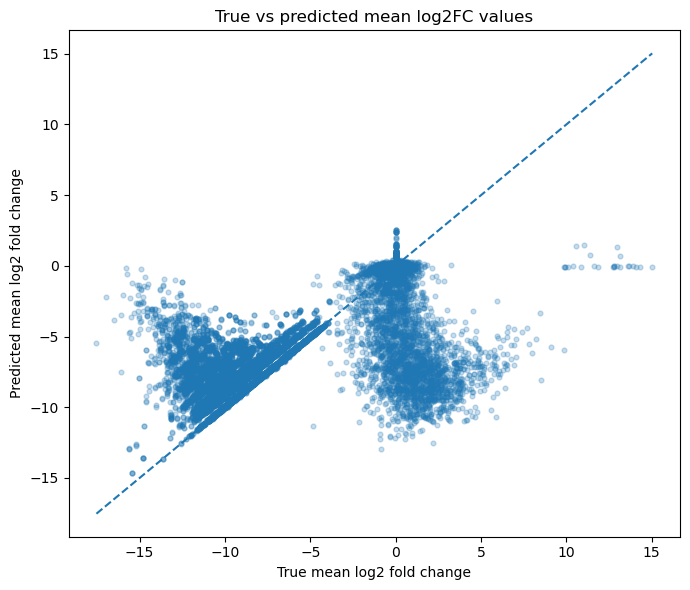


FINAL SUMMARY
Training perturbations: 40
Test perturbations: 10
Input features: ['baseline_expression', 'condition_Control', 'condition_IFNG', 'condition_Coculture']
Number of input features: 4
Number of predicted genes: 2000
Train-test perturbation overlap: 0


In [69]:
# Via linear baseline model in paper
# ============================================================
# 18. CREATE MODEL INPUT MATRIX
# ============================================================

condition_categories = [
    "Control",
    "IFNG",
    "Coculture"
]


def create_input_matrix(
    metadata
):
    """
    Create input features.

    Features:
        baseline_expression
        condition_Control
        condition_IFNG
        condition_Coculture
    """

    condition_encoded = pd.get_dummies(
        metadata[
            CONDITION_COLUMN
        ],
        prefix="condition",
        dtype=float
    )

    expected_condition_columns = [
        f"condition_{condition}"
        for condition in condition_categories
    ]

    condition_encoded = condition_encoded.reindex(
        columns=expected_condition_columns,
        fill_value=0.0
    )

    baseline_expression = (
        metadata[
            ["baseline_expression"]
        ]
        .astype(float)
        .reset_index(drop=True)
    )

    condition_encoded = (
        condition_encoded
        .reset_index(drop=True)
    )

    X = pd.concat(
        [
            baseline_expression,
            condition_encoded
        ],
        axis=1
    )

    return X


# ============================================================
# 19. CREATE MEAN LOG2FC TARGET MATRIX
# ============================================================

def create_target_matrix(
    metadata,
    profile_tables,
    output_genes
):
    """
    Create the multi-output target matrix.

    Rows:
        perturbation-condition observations

    Columns:
        output genes

    Values:
        mean log2 fold change
    """

    target_rows = []

    for _, row in metadata.iterrows():

        perturbation_name = row[
            PERTURBATION_COLUMN
        ]

        condition_name = row[
            CONDITION_COLUMN
        ]

        target_profile = (
            profile_tables[
                condition_name
            ]
            .loc[
                perturbation_name,
                output_genes
            ]
            .astype(float)
            .to_numpy()
        )

        target_rows.append(
            target_profile
        )

    Y = pd.DataFrame(
        np.vstack(
            target_rows
        ),
        columns=output_genes
    )

    return Y


# ============================================================
# 20. BUILD TRAINING AND TEST MATRICES
# ============================================================

X_train = create_input_matrix(
    train_metadata
)

X_test = create_input_matrix(
    test_metadata
)

Y_train = create_target_matrix(
    metadata=train_metadata,
    profile_tables=profile_tables,
    output_genes=common_output_genes
)

Y_test = create_target_matrix(
    metadata=test_metadata,
    profile_tables=profile_tables,
    output_genes=common_output_genes
)

print(
    "\nX_train shape:",
    X_train.shape
)

print(
    "Y_train shape:",
    Y_train.shape
)

print(
    "X_test shape:",
    X_test.shape
)

print(
    "Y_test shape:",
    Y_test.shape
)

print(
    "\nInput features:"
)

print(
    X_train.columns.tolist()
)


# ============================================================
# 21. VALIDATE MODEL MATRICES
# ============================================================

matrices = {
    "X_train": X_train,
    "X_test": X_test,
    "Y_train": Y_train,
    "Y_test": Y_test
}

for matrix_name, matrix in matrices.items():

    if matrix.isna().any().any():
        raise ValueError(
            f"{matrix_name} contains missing values."
        )

    if not np.isfinite(
        matrix.to_numpy(
            dtype=float
        )
    ).all():
        raise ValueError(
            f"{matrix_name} contains infinite values."
        )


# ============================================================
# 22. TRAIN MULTI-OUTPUT RIDGE REGRESSION
# ============================================================

model = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        ),
        (
            "regressor",
            Ridge(
                alpha=1.0
            )
        )
    ]
)

model.fit(
    X_train,
    Y_train
)

print(
    "\nModel training completed."
)


# ============================================================
# 23. PREDICT TEST LOG2FC PROFILES
# ============================================================

Y_predicted_array = model.predict(
    X_test
)

Y_predicted = pd.DataFrame(
    Y_predicted_array,
    columns=common_output_genes
)


# ============================================================
# 24. GLOBAL TEST-SET EVALUATION
# ============================================================

true_flat = Y_test.to_numpy().ravel()
predicted_flat = Y_predicted.to_numpy().ravel()

global_mae = mean_absolute_error(
    true_flat,
    predicted_flat
)

global_rmse = np.sqrt(
    mean_squared_error(
        true_flat,
        predicted_flat
    )
)

global_r2 = r2_score(
    true_flat,
    predicted_flat
)

global_correlation = np.corrcoef(
    true_flat,
    predicted_flat
)[0, 1]

print(
    "\n========================================"
)

print(
    "GLOBAL TEST RESULTS"
)

print(
    "========================================"
)

print(
    f"MAE:         {global_mae:.6f}"
)

print(
    f"RMSE:        {global_rmse:.6f}"
)

print(
    f"R²:          {global_r2:.6f}"
)

print(
    f"Correlation: {global_correlation:.6f}"
)


# ============================================================
# 25. EVALUATE EACH TEST PERTURBATION
# ============================================================

per_perturbation_results = []

for row_position in range(
    len(test_metadata)
):

    true_profile = (
        Y_test.iloc[
            row_position
        ].to_numpy()
    )

    predicted_profile = (
        Y_predicted.iloc[
            row_position
        ].to_numpy()
    )

    perturbation_mae = mean_absolute_error(
        true_profile,
        predicted_profile
    )

    perturbation_rmse = np.sqrt(
        mean_squared_error(
            true_profile,
            predicted_profile
        )
    )

    perturbation_r2 = r2_score(
        true_profile,
        predicted_profile
    )

    if (
        np.std(true_profile) > 0
        and np.std(predicted_profile) > 0
    ):

        profile_correlation = np.corrcoef(
            true_profile,
            predicted_profile
        )[0, 1]

    else:

        profile_correlation = np.nan

    per_perturbation_results.append(
        {
            "perturbation": test_metadata.loc[
                row_position,
                PERTURBATION_COLUMN
            ],
            "condition": test_metadata.loc[
                row_position,
                CONDITION_COLUMN
            ],
            "cluster": test_metadata.loc[
                row_position,
                CLUSTER_COLUMN
            ],
            "baseline_expression": test_metadata.loc[
                row_position,
                "baseline_expression"
            ],
            "MAE": perturbation_mae,
            "RMSE": perturbation_rmse,
            "R2": perturbation_r2,
            "profile_correlation": profile_correlation
        }
    )

per_perturbation_results = pd.DataFrame(
    per_perturbation_results
)

print(
    "\nResults for each test perturbation:"
)

print(
    per_perturbation_results
    .sort_values(
        by="profile_correlation",
        ascending=False
    )
    .to_string(
        index=False
    )
)


# ============================================================
# 26. CREATE PREDICTION TABLES WITH METADATA
# ============================================================

metadata_columns = [
    PERTURBATION_COLUMN,
    CONDITION_COLUMN,
    CLUSTER_COLUMN,
    "matched_target_gene",
    "baseline_expression"
]

predicted_log2fc_profiles = pd.concat(
    [
        test_metadata[
            metadata_columns
        ].reset_index(drop=True),

        Y_predicted.reset_index(drop=True)
    ],
    axis=1
)

true_log2fc_profiles = pd.concat(
    [
        test_metadata[
            metadata_columns
        ].reset_index(drop=True),

        Y_test.reset_index(drop=True)
    ],
    axis=1
)


# ============================================================
# 27. PLOT TRUE VS PREDICTED VALUES
# ============================================================

plt.figure(
    figsize=(7, 6)
)

plt.scatter(
    true_flat,
    predicted_flat,
    alpha=0.25,
    s=12
)

minimum_value = min(
    true_flat.min(),
    predicted_flat.min()
)

maximum_value = max(
    true_flat.max(),
    predicted_flat.max()
)

plt.plot(
    [
        minimum_value,
        maximum_value
    ],
    [
        minimum_value,
        maximum_value
    ],
    linestyle="--"
)

plt.xlabel(
    "True mean log2 fold change"
)

plt.ylabel(
    "Predicted mean log2 fold change"
)

plt.title(
    "True vs predicted mean log2FC values"
)

plt.tight_layout()

plt.show()


# ============================================================
# 28. SAVE RESULTS
# ============================================================

train_metadata.to_csv(
    "train_40_perturbations_metadata.csv",
    index=False
)

test_metadata.to_csv(
    "test_10_perturbations_metadata.csv",
    index=False
)

X_train.to_csv(
    "X_train_baseline_expression_condition.csv",
    index=False
)

X_test.to_csv(
    "X_test_baseline_expression_condition.csv",
    index=False
)

Y_train.to_csv(
    "Y_train_mean_log2fc_profiles.csv",
    index=False
)

Y_test.to_csv(
    "Y_test_true_mean_log2fc_profiles.csv",
    index=False
)

predicted_log2fc_profiles.to_csv(
    "Y_test_predicted_mean_log2fc_profiles.csv",
    index=False
)

true_log2fc_profiles.to_csv(
    "Y_test_true_mean_log2fc_profiles_with_metadata.csv",
    index=False
)

per_perturbation_results.to_csv(
    "test_perturbation_model_results.csv",
    index=False
)


# ============================================================
# 29. FINAL SUMMARY
# ============================================================

print(
    "\n========================================"
)

print(
    "FINAL SUMMARY"
)

print(
    "========================================"
)

print(
    "Training perturbations:",
    len(train_metadata)
)

print(
    "Test perturbations:",
    len(test_metadata)
)

print(
    "Input features:",
    X_train.columns.tolist()
)

print(
    "Number of input features:",
    X_train.shape[1]
)

print(
    "Number of predicted genes:",
    Y_train.shape[1]
)

print(
    "Train-test perturbation overlap:",
    len(
        train_perturbations.intersection(
            test_perturbations
        )
    )
)